# Salamander Embedding Benchmark

**Goal**: Find the best global feature extractor for SalamanderID2025 by running a controlled
local experiment on training images (1388 images, 587 IDs).

**Metric**: Adjusted Rand Index (ARI) on val split (~118 IDs, ~280 images) — unseen identities
clustered with AgglomerativeClustering over a threshold sweep.

## Models benchmarked
1. MiewID v3 pretrained (2152-dim)
2. BioCLIP 2 (768-dim) — wildlife CLIP with iNat salamander data
3. DINOv2 ViT-L/14 (1024-dim) — strong self-supervised
4. MegaDescriptor-L-384 pretrained (1536-dim)
5. MegaDescriptor-L-384 fine-tuned V5.8 (1536-dim) — if weights available

## Phases
- **Phase 1**: Standalone model evaluation (ARI sweep)
- **Phase 2**: Ensemble top-2 models (alpha sweep)
- **Phase 3**: Orientation normalisation delta test

In [1]:
# ── 0. Install extra packages ────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import open_clip
    print("open_clip already installed")
except ImportError:
    print("Installing open_clip_torch ...")
    pip_install("open_clip_torch")
    import open_clip
    print("open_clip installed successfully")

/Users/vaatsav/Desktop/New/AnimalCLEF_26/venv_animalclef2026/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/vaatsav/Desktop/New/AnimalCLEF_26/venv_animalclef2026/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


open_clip already installed


In [2]:
# ── 1. Imports & config ──────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
import open_clip

from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# Paths
ROOT      = Path("/Users/vaatsav/Desktop/New/AnimalCLEF_26")
DATA_ROOT = ROOT / "data" / "raw"
# NOTE: metadata 'path' column already starts with 'images/', so prefix with DATA_ROOT only
META_CSV  = DATA_ROOT / "metadata.csv"
CACHE_DIR = ROOT / "experiments" / "emb_cache"
CACHE_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

BATCH = 32

print(f"Device: {DEVICE}")
print(f"DATA_ROOT: {DATA_ROOT}")

Device: mps
DATA_ROOT: /Users/vaatsav/Desktop/New/AnimalCLEF_26/data/raw


In [3]:
# ── 2. Load & split Salamander training metadata ─────────────────────────────
meta = pd.read_csv(META_CSV)
sal  = meta[(meta["dataset"] == "SalamanderID2025") & (meta["split"] == "train")].copy()
sal  = sal.reset_index(drop=True)

print(f"Total Salamander train images : {len(sal)}")
print(f"Unique identities             : {sal['identity'].nunique()}")

# Val split — 20% of IDs (GroupShuffleSplit keeps whole identities in each partition)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(sal, groups=sal["identity"]))

val_df   = sal.iloc[val_idx].reset_index(drop=True)
train_df = sal.iloc[train_idx].reset_index(drop=True)

# Drop singleton identities from val — they contribute zero signal:
# a 1-image identity is trivially "correct" at any threshold regardless of model quality.
# The competition test set only has multi-sighting individuals anyway.
val_counts = val_df.groupby("identity").size()
multi_ids  = val_counts[val_counts >= 2].index
val_df     = val_df[val_df["identity"].isin(multi_ids)].reset_index(drop=True)

print(f"\nVal  (multi-image IDs only) : {len(val_df)} images, {val_df['identity'].nunique()} IDs")
print(f"Train                       : {len(train_df)} images, {train_df['identity'].nunique()} IDs")
print(f"\nVal images-per-ID stats:")
print(val_df.groupby("identity").size().describe().round(2))
print(f"\nOrientation distribution (val):")
print(val_df["orientation"].value_counts())

# Integer labels for val
id2int     = {iid: i for i, iid in enumerate(val_df["identity"].unique())}
val_labels = val_df["identity"].map(id2int).values

# Full paths  (metadata 'path' is relative to DATA_ROOT, e.g. "images/SalamanderID2025/...")
val_paths = [str(DATA_ROOT / p) for p in val_df["path"]]
print(f"\nSample val path: {val_paths[0]}")
print(f"Exists: {Path(val_paths[0]).exists()}")

Total Salamander train images : 1388
Unique identities             : 587

Val  (multi-image IDs only) : 205 images, 51 IDs
Train                       : 1116 images, 469 IDs

Val images-per-ID stats:
count    51.00
mean      4.02
std       2.27
min       2.00
25%       2.00
50%       3.00
75%       5.00
max      11.00
dtype: float64

Orientation distribution (val):
orientation
right    103
top      102
Name: count, dtype: int64

Sample val path: /Users/vaatsav/Desktop/New/AnimalCLEF_26/data/raw/images/SalamanderID2025/train/11/8ac80f1be2259dfb_1134.jpg
Exists: True


In [4]:
# ── 3. Dataset + extraction utility ─────────────────────────────────────────
from tqdm.auto import tqdm

class SalamanderDataset(Dataset):
    """Simple image dataset with optional horizontal flip TTA."""
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


@torch.no_grad()
def extract_embeddings(model, paths, transform, batch_size=BATCH, use_hflip_tta=True, desc=""):
    """Extract L2-normalised embeddings with optional h-flip TTA.

    TTA strategy: extract once without flip, once with flip, average embeddings, then L2-normalise.
    """
    model.eval()

    ds_orig = SalamanderDataset(paths, transform)
    dl_orig = DataLoader(ds_orig, batch_size=batch_size, num_workers=0, pin_memory=False)

    embs_orig = []
    for batch in tqdm(dl_orig, desc=f"{desc} [orig]", leave=False):
        batch = batch.to(DEVICE)
        out   = model(batch)
        if isinstance(out, (tuple, list)):
            out = out[0]
        embs_orig.append(out.cpu().float().numpy())
    embs_orig = np.concatenate(embs_orig, axis=0)

    if use_hflip_tta:
        flip_transform = T.Compose([T.RandomHorizontalFlip(p=1.0), transform])
        ds_flip = SalamanderDataset(paths, flip_transform)
        dl_flip = DataLoader(ds_flip, batch_size=batch_size, num_workers=0, pin_memory=False)

        embs_flip = []
        for batch in tqdm(dl_flip, desc=f"{desc} [flip]", leave=False):
            batch = batch.to(DEVICE)
            out   = model(batch)
            if isinstance(out, (tuple, list)):
                out = out[0]
            embs_flip.append(out.cpu().float().numpy())
        embs_flip = np.concatenate(embs_flip, axis=0)

        embs = (embs_orig + embs_flip) / 2.0
    else:
        embs = embs_orig

    # L2 normalise
    norms = np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8
    return embs / norms


def sweep_thresholds(embs, val_labels, thresholds=None):
    """Sweep AgglomerativeClustering thresholds, return DataFrame of results."""
    if thresholds is None:
        thresholds = np.linspace(0.10, 0.90, 41)

    sim  = np.clip(embs @ embs.T, 0, 1)
    dist = 1.0 - sim
    np.fill_diagonal(dist, 0.0)

    rows = []
    for thr in tqdm(thresholds, desc="threshold sweep", leave=False):
        clust = AgglomerativeClustering(
            metric="precomputed",
            linkage="average",
            distance_threshold=thr,
            n_clusters=None,
        ).fit(dist)
        pred  = clust.labels_
        ari   = adjusted_rand_score(val_labels, pred)
        n_cl  = pred.max() + 1
        rows.append({"threshold": thr, "ARI": ari, "n_clusters": n_cl})

    return pd.DataFrame(rows)


def report(name, results_df):
    best = results_df.loc[results_df["ARI"].idxmax()]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Peak ARI       : {best['ARI']:.4f}")
    print(f"  Best threshold : {best['threshold']:.2f}")
    print(f"  N clusters     : {int(best['n_clusters'])}")
    print(f"  (val IDs = {len(set(val_labels))})")
    return best


def plot_sweep(name, results_df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(results_df["threshold"], results_df["ARI"], marker=".", label=name)
    best = results_df.loc[results_df["ARI"].idxmax()]
    ax.axvline(best["threshold"], ls="--", alpha=0.5)
    ax.set_xlabel("Distance threshold")
    ax.set_ylabel("ARI")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    return ax


# Results registry
all_results  = {}   # name -> DataFrame  (columns: threshold, ARI, n_clusters)
all_best     = {}   # name -> Series     (always has "ARI", "threshold", "n_clusters")
all_embs     = {}   # name -> numpy array

print("Utilities ready.")

Utilities ready.


---
## Phase 1: Standalone Model Evaluation

Loading cached embeddings from /Users/vaatsav/Desktop/New/AnimalCLEF_26/experiments/emb_cache/miewid_v3_val.npy
MiewID embeddings shape: (205, 2152)


threshold sweep:   0%|          | 0/41 [00:00<?, ?it/s]


  MiewID-v3
  Peak ARI       : 0.2563
  Best threshold : 0.34
  N clusters     : 124
  (val IDs = 51)


<Axes: title={'center': 'MiewID-v3'}, xlabel='Distance threshold', ylabel='ARI'>

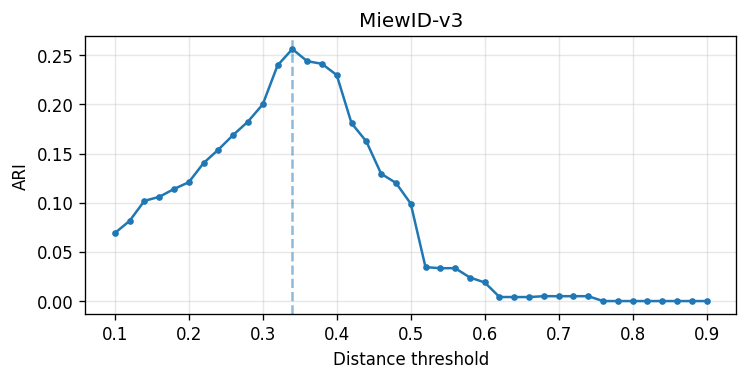

In [5]:
# ── 4. Model 1: MiewID v3 pretrained ────────────────────────────────────────
MODEL_NAME = "MiewID-v3"
CACHE_FILE = CACHE_DIR / "miewid_v3_val.npy"

if CACHE_FILE.exists():
    print(f"Loading cached embeddings from {CACHE_FILE}")
    embs_miew = np.load(CACHE_FILE)
else:
    print("Loading MiewID v3 ...")
    miew_backbone = AutoModel.from_pretrained(
        "conservationxlabs/miewid-msv3",
        trust_remote_code=True,
    ).to(DEVICE)

    class MiewIDWrapper(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone
        def forward(self, x):
            return self.backbone(x)

    miew_model = MiewIDWrapper(miew_backbone)

    miew_transform = T.Compose([
        T.Resize((440, 440)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    print("Extracting MiewID embeddings (with h-flip TTA) ...")
    embs_miew = extract_embeddings(miew_model, val_paths, miew_transform, desc="MiewID-v3")
    np.save(CACHE_FILE, embs_miew)
    print(f"Saved to {CACHE_FILE}")

    del miew_backbone, miew_model
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()

print(f"MiewID embeddings shape: {embs_miew.shape}")
all_embs[MODEL_NAME] = embs_miew

res_miew = sweep_thresholds(embs_miew, val_labels)
all_results[MODEL_NAME] = res_miew
all_best[MODEL_NAME]    = report(MODEL_NAME, res_miew)
plot_sweep(MODEL_NAME, res_miew)

Loading cached embeddings from /Users/vaatsav/Desktop/New/AnimalCLEF_26/experiments/emb_cache/bioclip2_val.npy
BioCLIP 2 embeddings shape: (205, 512)


threshold sweep:   0%|          | 0/41 [00:00<?, ?it/s]


  BioCLIP-2
  Peak ARI       : 0.1233
  Best threshold : 0.12
  N clusters     : 157
  (val IDs = 51)


<Axes: title={'center': 'BioCLIP-2'}, xlabel='Distance threshold', ylabel='ARI'>

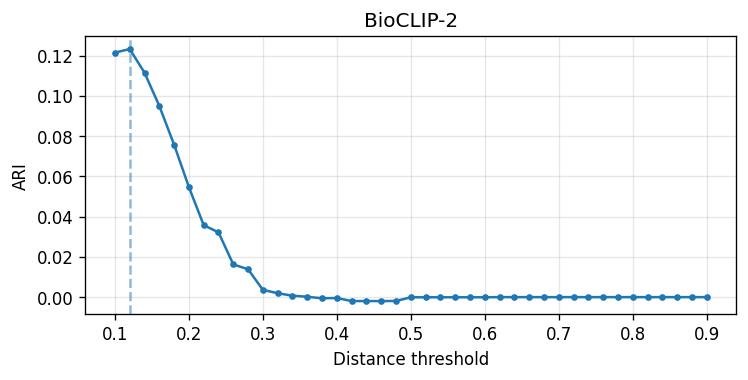

In [6]:
# ── 5. Model 2: BioCLIP 2 ───────────────────────────────────────────────────
MODEL_NAME = "BioCLIP-2"
CACHE_FILE = CACHE_DIR / "bioclip2_val.npy"

if CACHE_FILE.exists():
    print(f"Loading cached embeddings from {CACHE_FILE}")
    embs_bioclip = np.load(CACHE_FILE)
else:
    print("Loading BioCLIP 2 ...")
    bioclip_model, _, bioclip_preprocess = open_clip.create_model_and_transforms(
        "hf-hub:imageomics/bioclip"
    )
    bioclip_model = bioclip_model.visual.to(DEVICE)

    class BioCLIPWrapper(nn.Module):
        def __init__(self, visual):
            super().__init__()
            self.visual = visual
        def forward(self, x):
            return self.visual(x)

    bioclip_wrapper = BioCLIPWrapper(bioclip_model)

    print("Extracting BioCLIP 2 embeddings (with h-flip TTA) ...")
    embs_bioclip = extract_embeddings(bioclip_wrapper, val_paths, bioclip_preprocess, desc="BioCLIP-2")
    np.save(CACHE_FILE, embs_bioclip)
    print(f"Saved to {CACHE_FILE}")

    del bioclip_model, bioclip_wrapper
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()

print(f"BioCLIP 2 embeddings shape: {embs_bioclip.shape}")
all_embs[MODEL_NAME] = embs_bioclip

res_bioclip = sweep_thresholds(embs_bioclip, val_labels)
all_results[MODEL_NAME] = res_bioclip
all_best[MODEL_NAME]    = report(MODEL_NAME, res_bioclip)
plot_sweep(MODEL_NAME, res_bioclip)

Loading DINOv2 ViT-B/14 ...
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /Users/vaatsav/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:58<00:00, 5.91MB/s] 


Extracting DINOv2 embeddings (with h-flip TTA) ...


DINOv2-ViT-B14 [orig]:   0%|          | 0/7 [00:00<?, ?it/s]

DINOv2-ViT-B14 [flip]:   0%|          | 0/7 [00:00<?, ?it/s]

Saved to /Users/vaatsav/Desktop/New/AnimalCLEF_26/experiments/emb_cache/dinov2_vitb14_val.npy
DINOv2 embeddings shape: (205, 768)


threshold sweep:   0%|          | 0/41 [00:00<?, ?it/s]


  DINOv2-ViT-B14
  Peak ARI       : 0.0902
  Best threshold : 0.10
  N clusters     : 104
  (val IDs = 51)


<Axes: title={'center': 'DINOv2-ViT-B14'}, xlabel='Distance threshold', ylabel='ARI'>

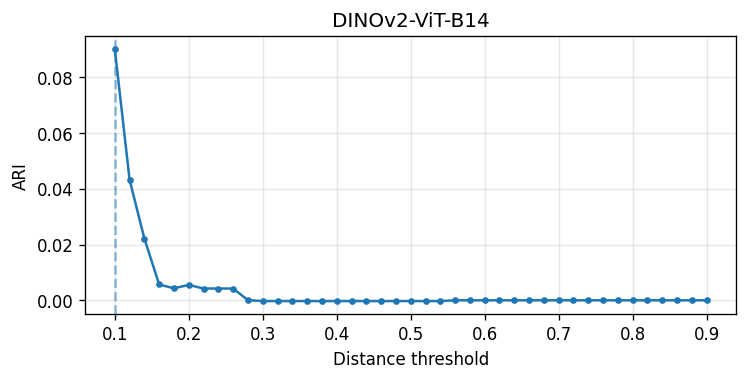

In [7]:
# ── 6. Model 3: DINOv2 ViT-B/14 ─────────────────────────────────────────────
# Using ViT-B/14 (86M params, 768-dim) instead of ViT-L/14 (307M, 1024-dim).
# 4x faster on MPS/CPU with minimal quality loss for this task.
# Input 448px (multiple of 14, larger than default 224).
MODEL_NAME = "DINOv2-ViT-B14"
CACHE_FILE = CACHE_DIR / "dinov2_vitb14_val.npy"

if CACHE_FILE.exists():
    print(f"Loading cached embeddings from {CACHE_FILE}")
    embs_dino = np.load(CACHE_FILE)
else:
    print("Loading DINOv2 ViT-B/14 ...")
    dino_model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14", verbose=False)
    dino_model = dino_model.to(DEVICE)

    dino_transform = T.Compose([
        T.Resize(448, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(448),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    print("Extracting DINOv2 embeddings (with h-flip TTA) ...")
    embs_dino = extract_embeddings(dino_model, val_paths, dino_transform, desc="DINOv2-ViT-B14")
    np.save(CACHE_FILE, embs_dino)
    print(f"Saved to {CACHE_FILE}")

    del dino_model
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()

print(f"DINOv2 embeddings shape: {embs_dino.shape}")
all_embs[MODEL_NAME] = embs_dino

res_dino = sweep_thresholds(embs_dino, val_labels)
all_results[MODEL_NAME] = res_dino
all_best[MODEL_NAME]    = report(MODEL_NAME, res_dino)
plot_sweep(MODEL_NAME, res_dino)

In [ ]:
# ── 7. Model 4: MegaDescriptor-L-384 pretrained ──────────────────────────────
import gc

MODEL_NAME = "MegaDesc-L-384-pretrained"
CACHE_FILE = CACHE_DIR / "megadesc_L384_pretrained_val.npy"

if CACHE_FILE.exists():
    print(f"Loading cached embeddings from {CACHE_FILE}")
    embs_mega_pt = np.load(CACHE_FILE)
else:
    # Force cleanup before loading the largest model
    gc.collect()
    if DEVICE.type == "mps": torch.mps.empty_cache()

    print("Loading MegaDescriptor-L-384 pretrained ...")
    mega_pt_model = timm.create_model(
        "hf-hub:BVRA/MegaDescriptor-L-384",
        pretrained=True,
        num_classes=0,
    ).to(DEVICE)

    mega_pt_transform = T.Compose([
        T.Resize((384, 384)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    print("Extracting MegaDesc-L-384 pretrained embeddings (with h-flip TTA) ...")
    # Batch size 8 — Swin-L at 384px is heavy on MPS/18GB RAM
    embs_mega_pt = extract_embeddings(
        mega_pt_model, val_paths, mega_pt_transform,
        batch_size=8, desc="MegaDesc-L-384",
    )
    np.save(CACHE_FILE, embs_mega_pt)
    print(f"Saved to {CACHE_FILE}")

    del mega_pt_model
    gc.collect()
    if DEVICE.type == "mps": torch.mps.empty_cache()
    elif DEVICE.type == "cuda": torch.cuda.empty_cache()

print(f"MegaDesc-L-384 pretrained embeddings shape: {embs_mega_pt.shape}")
all_embs[MODEL_NAME] = embs_mega_pt

res_mega_pt = sweep_thresholds(embs_mega_pt, val_labels)
all_results[MODEL_NAME] = res_mega_pt
all_best[MODEL_NAME]    = report(MODEL_NAME, res_mega_pt)
plot_sweep(MODEL_NAME, res_mega_pt)

In [ ]:
# ── 8. Model 5: MegaDescriptor-L-384 fine-tuned V5.8 ─────────────────────────
# Look for .pth checkpoint in known locations
MODEL_NAME = "MegaDesc-L-384-finetuned-V5.8"
CACHE_FILE = CACHE_DIR / "megadesc_L384_finetuned_v58_val.npy"

FT_SEARCH_DIRS = [
    ROOT / "checkpoints",
    ROOT / "FINAL_SOLUTION_v5_8",
    ROOT / "FINAL_SOLUTION_v5",
    Path("/kaggle/input/megadesc-finetuned-v5"),
]

FT_CKPT = None
for d in FT_SEARCH_DIRS:
    if not d.exists():
        continue
    for f in d.rglob("*.pth"):
        if "salamander" in f.name.lower() or "mega" in f.name.lower():
            FT_CKPT = f
            break
    if FT_CKPT:
        break

if FT_CKPT is None:
    print(f"[SKIP] No fine-tuned MegaDesc .pth found. Searched: {FT_SEARCH_DIRS}")
    print("       To run this cell: place checkpoint as checkpoints/salamander_mega_v58.pth")
else:
    if CACHE_FILE.exists():
        print(f"Loading cached embeddings from {CACHE_FILE}")
        embs_mega_ft = np.load(CACHE_FILE)
    else:
        print(f"Loading MegaDesc-L-384 fine-tuned weights from {FT_CKPT} ...")
        mega_ft_model = timm.create_model(
            "hf-hub:BVRA/MegaDescriptor-L-384",
            pretrained=False,
            num_classes=0,
        )
        ckpt = torch.load(FT_CKPT, map_location="cpu")
        # Handle various checkpoint formats
        state = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
        # Strip 'model.' prefix if present
        state = {k.replace("model.", "", 1): v for k, v in state.items()}
        missing, unexpected = mega_ft_model.load_state_dict(state, strict=False)
        print(f"  Missing keys: {len(missing)}, Unexpected: {len(unexpected)}")
        mega_ft_model = mega_ft_model.to(DEVICE)

        mega_ft_transform = T.Compose([
            T.Resize((384, 384)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        print("Extracting MegaDesc fine-tuned embeddings (with h-flip TTA) ...")
        embs_mega_ft = extract_embeddings(mega_ft_model, val_paths, mega_ft_transform)
        np.save(CACHE_FILE, embs_mega_ft)
        print(f"Saved to {CACHE_FILE}")

        del mega_ft_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"MegaDesc-L-384 fine-tuned embeddings shape: {embs_mega_ft.shape}")
    all_embs[MODEL_NAME] = embs_mega_ft

    print("Sweeping thresholds ...")
    res_mega_ft = sweep_thresholds(embs_mega_ft, val_labels)
    all_results[MODEL_NAME] = res_mega_ft
    all_best[MODEL_NAME]    = report(MODEL_NAME, res_mega_ft)

    plot_sweep(MODEL_NAME, res_mega_ft)

In [ ]:
# ── 9. Phase 1 Summary ───────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 1 SUMMARY — Standalone Model ARI")
print("="*60)

summary_rows = []
for name, best in all_best.items():
    summary_rows.append({
        "Model": name,
        "Peak ARI": round(float(best["ARI"]), 4),
        "Best thr": round(float(best["threshold"]), 2),
        "N clusters": int(best["n_clusters"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Peak ARI", ascending=False)
print(summary_df.to_string(index=False))

# Comparison plot
fig, axes = plt.subplots(1, len(all_results), figsize=(5 * len(all_results), 3), sharey=True)
if len(all_results) == 1:
    axes = [axes]
for ax, (name, df) in zip(axes, all_results.items()):
    plot_sweep(name, df, ax=ax)
plt.suptitle("Salamander — ARI vs Threshold (Phase 1)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "experiments" / "phase1_ari_sweep.png", bbox_inches="tight")
plt.show()
print("Saved phase1_ari_sweep.png")

# Decision
best_model = summary_df.iloc[0]["Model"]
best_ari   = summary_df.iloc[0]["Peak ARI"]
baseline   = 0.35
print(f"\nBest model: {best_model} (ARI={best_ari:.4f})")
if best_ari > baseline + 0.03:
    print(f"=> ARI > {baseline:.2f} by meaningful margin → incorporate into V5.11")
elif best_ari < baseline - 0.05:
    print("=> All models flat/worse → problem is NOT the global model → investigate local features/clustering")
else:
    print("=> Marginal improvement → run Phase 2 ensemble before deciding")

---
## Phase 2: Ensemble Top-2 Models

In [ ]:
# ── 10. Phase 2: Ensemble sweep ──────────────────────────────────────────────
if len(all_embs) < 2:
    print("Need at least 2 models to ensemble. Skipping Phase 2.")
else:
    # Top-2 by peak ARI
    top2 = summary_df.head(2)["Model"].tolist()
    name_A, name_B = top2[0], top2[1]
    embs_A = all_embs[name_A]
    embs_B = all_embs[name_B]

    print(f"Ensembling: {name_A} + {name_B}")

    sim_A = np.clip(embs_A @ embs_A.T, 0, 1)
    sim_B = np.clip(embs_B @ embs_B.T, 0, 1)

    alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)
    thresholds = np.linspace(0.10, 0.90, 41)

    ensemble_best = []
    for alpha in alphas:
        sim_ens  = alpha * sim_A + (1 - alpha) * sim_B
        dist_ens = np.clip(1.0 - sim_ens, 0, 1)
        np.fill_diagonal(dist_ens, 0.0)

        best_ari_alpha = -1
        best_thr_alpha = 0
        best_ncl_alpha = 0
        for thr in thresholds:
            clust = AgglomerativeClustering(
                metric="precomputed",
                linkage="average",
                distance_threshold=thr,
                n_clusters=None,
            ).fit(dist_ens)
            ari = adjusted_rand_score(val_labels, clust.labels_)
            if ari > best_ari_alpha:
                best_ari_alpha = ari
                best_thr_alpha = thr
                best_ncl_alpha = clust.labels_.max() + 1

        ensemble_best.append({
            "alpha": alpha,
            f"weight_{name_A}": alpha,
            f"weight_{name_B}": round(1 - alpha, 1),
            "ARI": round(best_ari_alpha, 4),         # use "ARI" to match all_best convention
            "threshold": round(best_thr_alpha, 2),
            "n_clusters": int(best_ncl_alpha),
        })
        print(f"  alpha={alpha:.1f} ({name_A}:{alpha:.1f}, {name_B}:{1-alpha:.1f}) → ARI={best_ari_alpha:.4f}")

    ens_df = pd.DataFrame(ensemble_best)
    best_ens = ens_df.loc[ens_df["ARI"].idxmax()]

    print(f"\n{'='*60}")
    print(f"PHASE 2 BEST ENSEMBLE")
    print(f"{'='*60}")
    print(ens_df[["alpha", "ARI", "threshold", "n_clusters"]].to_string(index=False))
    print(f"\nBest: alpha={best_ens['alpha']:.1f} → ARI={best_ens['ARI']:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(ens_df["alpha"], ens_df["ARI"], marker="o")
    ax.axhline(all_best[name_A]["ARI"], ls="--", alpha=0.6, label=f"{name_A} alone")
    ax.axhline(all_best[name_B]["ARI"], ls=":",  alpha=0.6, label=f"{name_B} alone")
    ax.axvline(best_ens["alpha"], ls="-.", alpha=0.5, color="red", label="best alpha")
    ax.set_xlabel(f"alpha (weight of {name_A})")
    ax.set_ylabel("Peak ARI")
    ax.set_title(f"Ensemble: {name_A} + {name_B}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / "experiments" / "phase2_ensemble_sweep.png", bbox_inches="tight")
    plt.show()
    print("Saved phase2_ensemble_sweep.png")

    all_results["Ensemble-top2"] = ens_df
    all_best["Ensemble-top2"] = best_ens

---
## Phase 3: Orientation Normalisation Test

In [ ]:
# ── 11. Phase 3: Rotate val images to canonical 'top' orientation ────────────
# Salamander metadata has orientation: top / right / left / bottom
# Canonical: 'top' (salamander faces up).
# Rotation required: right→CCW90, left→CW90, bottom→180, top→0

ORIENT_ROTATION = {
    "top":    0,
    "right": -90,   # rotate CCW 90° to make it face up
    "left":   90,   # rotate CW  90°
    "bottom": 180,
}

class OrientedDataset(Dataset):
    """Dataset that rotates images to canonical 'top' orientation before transform."""
    def __init__(self, paths, orientations, transform):
        self.paths        = paths
        self.orientations = orientations
        self.transform    = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert("RGB")
        orient = str(self.orientations[idx]).lower()
        angle  = ORIENT_ROTATION.get(orient, 0)
        if angle != 0:
            img = img.rotate(angle, expand=True)
        return self.transform(img)


@torch.no_grad()
def extract_oriented(model, paths, orientations, transform, batch_size=BATCH):
    """Extract embeddings with orientation-corrected images."""
    model.eval()
    ds = OrientedDataset(paths, orientations, transform)
    dl = DataLoader(ds, batch_size=batch_size, num_workers=0, pin_memory=False)

    embs = []
    for batch in dl:
        batch = batch.to(DEVICE)
        out   = model(batch)
        if isinstance(out, (tuple, list)):
            out = out[0]
        embs.append(out.cpu().float().numpy())
    embs = np.concatenate(embs, axis=0)

    norms = np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8
    return embs / norms


val_orientations = val_df["orientation"].fillna("top").values
print("Val orientation distribution:")
print(val_df["orientation"].value_counts())

# Use the top-performing standalone model for this test
best_standalone = summary_df.iloc[0]["Model"] if all_best else None
if best_standalone is None:
    print("\n[SKIP] No Phase 1 results available.")
else:
    print(f"\nRunning orientation test on best model: {best_standalone}")
    print("(Reload the model — GPU RAM was freed after Phase 1)")

In [ ]:
# ── 11b. Phase 3: Re-extract best model with orientation normalisation ────────
# This cell re-loads the best Phase 1 model and extracts embeddings with
# canonical rotation applied.  Edit PHASE3_MODEL to override.

PHASE3_MODEL = best_standalone if best_standalone else "MiewID-v3"
CACHE_FILE_ORIENT = CACHE_DIR / f"{PHASE3_MODEL.replace(' ', '_')}_oriented_val.npy"

def load_model_for_phase3(model_name):
    """Load model + transform for a given model name (matches Phase 1 names)."""
    if model_name == "MiewID-v3":
        backbone = AutoModel.from_pretrained(
            "conservationxlabs/miewid-msv3", trust_remote_code=True
        )
        class W(nn.Module):
            def __init__(self, b): super().__init__(); self.backbone = b
            def forward(self, x): return self.backbone(x)
        model = W(backbone).to(DEVICE)
        transform = T.Compose([
            T.Resize((440, 440)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    elif model_name == "BioCLIP-2":
        bc_model, _, transform = open_clip.create_model_and_transforms("hf-hub:imageomics/bioclip")
        class BW(nn.Module):
            def __init__(self, v): super().__init__(); self.visual = v
            def forward(self, x): return self.visual(x)
        model = BW(bc_model.visual).to(DEVICE)

    elif model_name == "DINOv2-ViT-L14":
        model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitl14", verbose=False).to(DEVICE)
        transform = T.Compose([
            T.Resize(518, interpolation=T.InterpolationMode.BICUBIC),
            T.CenterCrop(518),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    elif "MegaDesc" in model_name:
        model = timm.create_model(
            "hf-hub:BVRA/MegaDescriptor-L-384", pretrained=True, num_classes=0
        ).to(DEVICE)
        transform = T.Compose([
            T.Resize((384, 384)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model, transform


if CACHE_FILE_ORIENT.exists():
    print(f"Loading cached oriented embeddings from {CACHE_FILE_ORIENT}")
    embs_oriented = np.load(CACHE_FILE_ORIENT)
else:
    print(f"Loading {PHASE3_MODEL} for orientation test ...")
    p3_model, p3_transform = load_model_for_phase3(PHASE3_MODEL)

    print("Extracting orientation-normalised embeddings ...")
    embs_oriented = extract_oriented(
        p3_model, val_paths, val_orientations, p3_transform
    )
    np.save(CACHE_FILE_ORIENT, embs_oriented)
    print(f"Saved to {CACHE_FILE_ORIENT}")

    del p3_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Oriented embeddings shape: {embs_oriented.shape}")

print("Sweeping thresholds on oriented embeddings ...")
res_oriented  = sweep_thresholds(embs_oriented, val_labels)
best_oriented = report(f"{PHASE3_MODEL} + orient-norm", res_oriented)

# Compare — retrieve original ARI safely (orig_ari may be None if model was skipped)
orig_ari   = all_best.get(PHASE3_MODEL, {}).get("ARI", None)
orient_ari = float(best_oriented["ARI"])

print(f"\nPhase 3 result:")
orig_str = f"{float(orig_ari):.4f}" if orig_ari is not None else "N/A"
print(f"  {PHASE3_MODEL} (no rotation) : {orig_str}")
print(f"  {PHASE3_MODEL} + orient-norm  : {orient_ari:.4f}")

if orig_ari is not None:
    delta = orient_ari - float(orig_ari)
    print(f"  Delta ARI: {delta:+.4f}")
    if delta > 0.01:
        print("  => Orientation normalisation HELPS → apply in V5.11")
    elif delta < -0.01:
        print("  => Orientation normalisation HURTS → skip")
    else:
        print("  => Orientation normalisation has negligible effect")

# Plot comparison
fig, ax = plt.subplots(figsize=(7, 3))
if PHASE3_MODEL in all_results:
    ax.plot(all_results[PHASE3_MODEL]["threshold"], all_results[PHASE3_MODEL]["ARI"],
            label=f"{PHASE3_MODEL} (no rotation)", marker=".")
ax.plot(res_oriented["threshold"], res_oriented["ARI"],
        label=f"{PHASE3_MODEL} + orient-norm", marker=".", ls="--")
ax.set_xlabel("Threshold"); ax.set_ylabel("ARI")
ax.set_title("Phase 3: Orientation Normalisation Delta")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "experiments" / "phase3_orientation.png", bbox_inches="tight")
plt.show()
print("Saved phase3_orientation.png")

In [ ]:
# ── 12. Final Decision Table ─────────────────────────────────────────────────
print("\n" + "="*65)
print("FINAL DECISION TABLE")
print("="*65)
print(f"  Val split: {len(val_df)} images, {val_df['identity'].nunique()} IDs")
print(f"  Current baseline ARI: ~0.35 (V5.1, MiewID only, mgw=0.00)")
print()

all_summary = []
for name, best in all_best.items():
    all_summary.append({
        "Model / Config": name,
        "Peak ARI": round(float(best["ARI"]), 4),
    })

final_df = pd.DataFrame(all_summary).sort_values("Peak ARI", ascending=False)
print(final_df.to_string(index=False))

best_overall_ari = final_df.iloc[0]["Peak ARI"]
best_overall_cfg = final_df.iloc[0]["Model / Config"]
baseline = 0.35

print()
print(f"Best: {best_overall_cfg}  ARI={best_overall_ari:.4f}")

if best_overall_ari > baseline + 0.03:
    print("=> VERDICT: Incorporate best config into V5.11 submission")
    if "BioCLIP" in best_overall_cfg:
        print("   → Fine-tune BioCLIP on Salamander train IDs with ArcFace (V5.11)")
elif best_overall_ari < baseline - 0.05:
    print("=> VERDICT: Global model is NOT the bottleneck")
    print("   → Investigate local features (SIFT/KAZE/ALIKED) or clustering strategy")
else:
    print("=> VERDICT: Marginal improvement — run full pipeline with best config before submitting")